# 🍄 Mushroom Toxicity Classifier Using Machine Learning
### CSE422 Lab Project Code Report
---

## 1. Introduction

### 🌿 Project Overview
This project aims to build a **mushroom toxicity classifier** — a machine learning system that can predict whether a mushroom is **poisonous (p)** or **edible (e)** based on its physical and environmental characteristics.

### ❓ Problem Statement
Mushroom foraging is a popular activity worldwide, but misidentification of poisonous mushrooms leads to thousands of poisonings — and sometimes deaths — every year. Traditional identification requires expert knowledge of dozens of visual and habitat-based cues. This is a **high-stakes classification problem** where false negatives (misclassifying a poisonous mushroom as edible) can be fatal.

### 💡 Motivation
By training a machine learning model on labeled mushroom data, we can create a tool that assists foragers, botanists, and food safety inspectors in rapidly and accurately identifying dangerous mushroom species. The model learns non-obvious relationships between features (cap shape, gill color, habitat, season, etc.) and toxicity that would be difficult for a human to memorize or reason about manually.

### 🎯 Objectives
- Perform thorough **Exploratory Data Analysis (EDA)** to understand the dataset.
- Apply appropriate **data preprocessing** (handling missing values using SimpleImputer, encoding, scaling).
- Train and compare **four supervised learning models**: K-Nearest Neighbors (KNN), Logistic Regression, Naïve Bayes, and a Neural Network (via TensorFlow/Keras).
- Apply **unsupervised clustering (K-Means)** to explore natural groupings in the data.
- Select the **best-performing model** using comprehensive evaluation metrics.


---
## 2. Dataset Description

### 📦 Loading Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, precision_score, recall_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

import warnings

warnings.filterwarnings('ignore')







# Load dataset directly from public Google Drive link  https://drive.google.com/file/d/1c22q9y_8ecjPvUqi30LUz1AUMMiuv78p
FILE_ID = '1c22q9y_8ecjPvUqi30LUz1AUMMiuv78p'
DRIVE_CSV_URL = f'https://drive.google.com/uc?export=download&id={FILE_ID}'
# Load dataset (semicolon-separated)
df = pd.read_csv('/content/sample_data/mushroom_dataset.csv', sep=';')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (61069, 21)


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


### 📊 How Many Features?

The dataset contains **21 columns** total:
- **1 target column** → `class` (poisonous `p` or edible `e`)
- **20 feature columns** → physical and environmental attributes of mushrooms


In [ ]:
# Feature overview
print(f"Total columns: {df.shape[1]}")
print(f"Total rows (data points): {df.shape[0]:,}")
print()
df.info()
print()
print("Column names and data types:")

Total columns: 21
Total rows (data points): 61,069

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type         

### 🔢 How Many Data Points?
The dataset contains **61,069 mushroom observations** — a substantial dataset suitable for training robust ML models.

### 📌 Classification or Regression Problem?

This is a **Classification Problem** because:
- The target variable `class` is a **discrete categorical variable** with exactly two values: **`p` (poisonous)** and **`e` (edible)**.
- We are predicting a **category/label**, not a continuous numerical value.
- Binary classification is the appropriate task here.

### 🔍 Feature Types

The dataset contains a mix of feature types:
- **Quantitative (Numerical)**: `cap-diameter`, `stem-height`, `stem-width` → continuous measurements in cm
- **Categorical**: All remaining 17 columns — properties like shape, color, surface texture, habitat, and season encoded as short letter codes


In [ ]:
# Separate numerical and categorical features
numerical_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()
# Remove target 'class' from categorical_features for analysis
categorical_features_no_target = [c for c in categorical_features if c != 'class']

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print()
print(f"Categorical features (excluding target) ({len(categorical_features_no_target)}):")
for f in categorical_features_no_target:
    print(f"  - {f}")

Numerical features (3): ['cap-diameter', 'stem-height', 'stem-width']

Categorical features (excluding target) (17):
  - cap-shape
  - cap-surface
  - cap-color
  - does-bruise-or-bleed
  - gill-attachment
  - gill-spacing
  - gill-color
  - stem-root
  - stem-surface
  - stem-color
  - veil-type
  - veil-color
  - has-ring
  - ring-type
  - spore-print-color
  - habitat
  - season


### 🔡 Do We Need to Encode Categorical Variables?

**Yes, absolutely.** Most ML algorithms (Logistic Regression, Neural Networks) work with **numerical inputs only** and cannot process string labels. We must convert categorical columns to numerical representations.

We will use **Label Encoding** for this dataset — each unique category is assigned an integer.

### 🔥 Correlation Analysis


In [73]:
# Encode the full dataset temporarily for correlation analysis
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype(str)
        df_encoded[col] = le.fit_transform(df_encoded[col])


In [74]:
df_encoded.head()


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,1,15.26,6,2,6,0,2,3,10,16.95,...,5,8,11,1,5,1,2,3,0,3
1,1,16.60,6,2,6,0,2,3,10,17.99,...,5,8,11,1,5,1,2,3,0,2
2,1,14.07,6,2,6,0,2,3,10,17.80,...,5,8,11,1,5,1,2,3,0,3
3,1,14.17,2,3,1,0,2,3,10,15.77,...,5,8,11,1,5,1,6,3,0,3
4,1,14.64,6,3,6,0,2,3,10,16.53,...,5,8,11,1,5,1,6,3,0,3


In [75]:
# Compute correlation matrix
corr_matrix = df_encoded.corr()
corr_matrix

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
class,1.000000,-0.181139,-0.106309,-0.025475,0.026411,-0.019889,-0.058147,-0.004267,-0.060701,-0.121593,...,0.062233,-0.135955,-0.094772,0.052677,-0.093362,0.057559,0.066880,-0.048572,-0.041923,-0.054046
cap-diameter,-0.181139,1.000000,0.103923,0.087789,0.042108,0.179440,0.113197,0.089849,0.221675,0.422560,...,0.097406,0.014035,0.008670,0.082387,0.042068,0.077024,0.050473,0.091020,-0.125820,0.037305
cap-shape,-0.106309,0.103923,1.000000,-0.074510,0.016312,0.191804,-0.058315,0.126598,0.115703,0.034473,...,0.014161,0.068737,0.009061,-0.034247,-0.012551,0.036017,0.152296,0.036398,-0.124754,-0.027178
cap-surface,-0.025475,0.087789,-0.074510,1.000000,0.118919,-0.086619,0.046476,-0.074238,-0.015406,0.088686,...,-0.033981,0.008585,0.110085,-0.035473,0.007876,0.130888,-0.010990,0.069757,0.087488,0.019385
cap-color,0.026411,0.042108,0.016312,0.118919,1.000000,0.010657,0.009339,-0.110547,0.136560,-0.010732,...,0.067840,-0.036894,0.265525,0.051035,0.045818,0.070843,0.003988,0.011150,0.031706,0.008443
does-bruise-or-bleed,-0.019889,0.179440,0.191804,-0.086619,0.010657,1.000000,-0.019299,0.064375,0.018613,0.076596,...,0.071555,0.077949,-0.024913,-0.038548,-0.010202,0.019195,-0.009070,-0.006290,-0.102747,-0.051146
gill-attachment,-0.058147,0.113197,-0.058315,0.046476,0.009339,-0.019299,1.000000,-0.016785,0.051498,0.109694,...,-0.130906,-0.054615,0.055362,-0.038658,0.042935,-0.098437,-0.079841,-0.054908,-0.125626,-0.040428
gill-spacing,-0.004267,0.089849,0.126598,-0.074238,-0.110547,0.064375,-0.016785,1.000000,-0.062813,0.197890,...,0.100178,0.066423,-0.068988,0.089885,0.129650,0.025547,0.054903,0.001237,-0.128208,-0.028954
gill-color,-0.060701,0.221675,0.115703,-0.015406,0.136560,0.018613,0.051498,-0.062813,1.000000,0.157327,...,-0.069477,0.050428,0.149863,0.175839,0.155644,-0.055640,0.022302,0.136223,-0.075768,-0.011360
stem-height,-0.121593,0.422560,0.034473,0.088686,-0.010732,0.076596,0.109694,0.197890,0.157327,1.000000,...,0.237081,0.235860,0.138458,0.298777,0.203839,0.281049,0.225737,-0.004036,-0.020664,-0.020630


Here:Pearson Correlation              
**corr**= +1 indicates perfect positive correlation

corr = –1 indicates perfect negative correlation

corr = 0 indicates no correlation

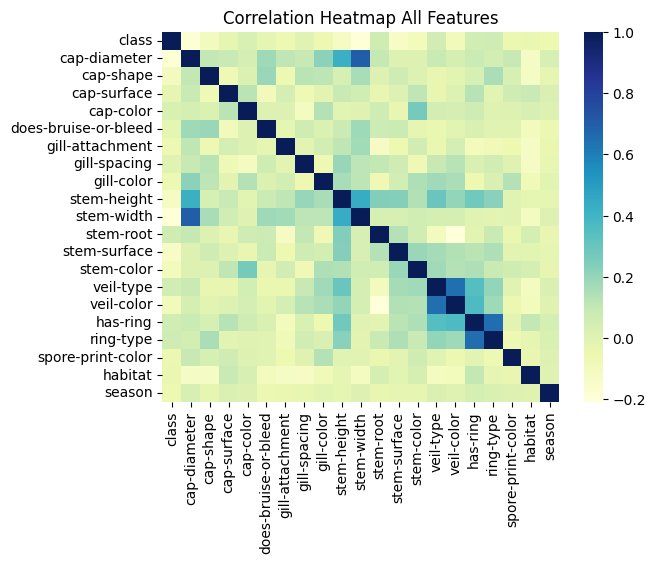

In [76]:
# Plot heatmap
sns.heatmap(
    corr_matrix,
    cmap='YlGnBu',)
plt.title('Correlation Heatmap All Features')
plt.show()

### 📝 What Do We Understand from the Correlation Analysis?

Key observations from the heatmap:
1. **`spore-print-color`** shows a moderate positive correlation with `class`.
2. **`gill-color`**, **`ring-type`**, **`habitat`**, and **`has-ring`** also show non-trivial correlations with `class`.
3. **`cap-diameter`**, **`stem-height`**, and **`stem-width`** are moderately **correlated with each other** (size dimensions naturally co-vary).
4. Several features are weakly correlated, indicating that combining multiple features rather than relying on any single predictor is necessary.

### ⚖️ Imbalanced Dataset Analysis


In [140]:
#check Imbalance in data

#group instances based on the classes in the target variable
# Mapping 'e' and 'p' to 0 and 1 for the logic provided in the template
class_counts = df['class'].value_counts()
# Mapping: e -> 0, p -> 1
counts_mapped = {0: class_counts.get('e', 0), 1: class_counts.get('p', 0)}

columns = ['outcome', 'count', 'percentage']
outcome = [0, 1]
count = list()
percentage = list()

# Calculate the percentage of each value from total
total_instances = len(df)
for val in range(2):
    count.append(counts_mapped[val])
    percent = (counts_mapped[val] / total_instances) * 100
    percentage.append(percent)

# Convert the calculated values into a dataframe
imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)), columns=columns)
imbalance_df

,outcome,count,percentage
0,0,27181,44.508671
1,1,33888,55.491329


**Barplot of Outcome vs Percentage**

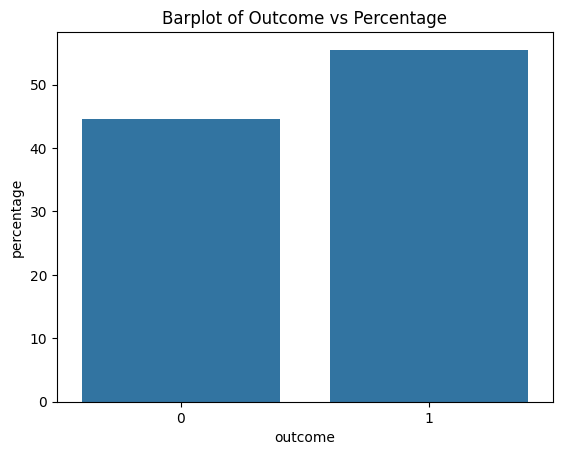

In [141]:
sns.barplot(data=imbalance_df, x='outcome', y='percentage')
plt.title('Barplot of Outcome vs Percentage')
plt.show()

### For the output feature, do all unique classes have an equal number of instances or not?

No, all unique classes do not have an equal number of instances. The dataset is mildly imbalanced.

### Represent using a bar chart of N classes (N=number of classes you have in your dataset).

The bar chart generated above (`co11`) visually represents the distribution of the two classes ('Edible' and 'Poisonous') in the dataset.

### 🔎 Exploratory Data Analysis (EDA)

EDA helps us discover patterns, relationships, and anomalies in the data before modeling.


## Selecting numerical features

In [122]:
numerical_data = df.select_dtypes(include='number')
# Transposed stats for numerical features
display(numerical_data.describe().T)

,count,mean,std,min,25%,50%,75%,max
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91


### **Summary satistics of Categorical features**

In [123]:
categorical_data = df.select_dtypes(include='object')
# Transposed stats for categorical features
display(categorical_data.describe().T)

,count,unique,top,freq
class,61069,2,p,33888
cap-shape,61069,7,x,26934
cap-surface,46949,11,t,8196
cap-color,61069,12,n,24218
does-bruise-or-bleed,61069,2,f,50479
gill-attachment,51185,7,a,12698
gill-spacing,36006,3,c,24710
gill-color,61069,12,w,18521
stem-root,9531,5,s,3177
stem-surface,22945,8,s,6025


### **Variance of each numerical features**

In [124]:
display(numerical_data.var())

,0
cap-diameter,27.718592
stem-height,11.357014
stem-width,100.720394


### Skew in numerical features

◤ **What is Skewness?**
Skewness measures the asymmetry of the distribution of a dataset.
* **Skewness = 0** → Perfectly symmetrical (e.g., normal distribution)
* **Skewness < 0** → Left-skewed (long tail on the left)
* **Skewness > 0** → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

📊 **Interpretation of Skewness Values:**

| Skewness Value | Interpretation |
| :--- | :--- |
| ~ 0 | Symmetrical (normal-ish) |
| 0 to ±0.5 | Fairly symmetrical |
| ±0.5 to ±1 | Moderately skewed |
| greater than ±1 | Highly skewed |

In [125]:
display(numerical_data.skew())

,0
cap-diameter,3.822844
stem-height,2.020904
stem-width,2.164957


### Histograms and Box Plot
To find the distributions and outlier in the each feature

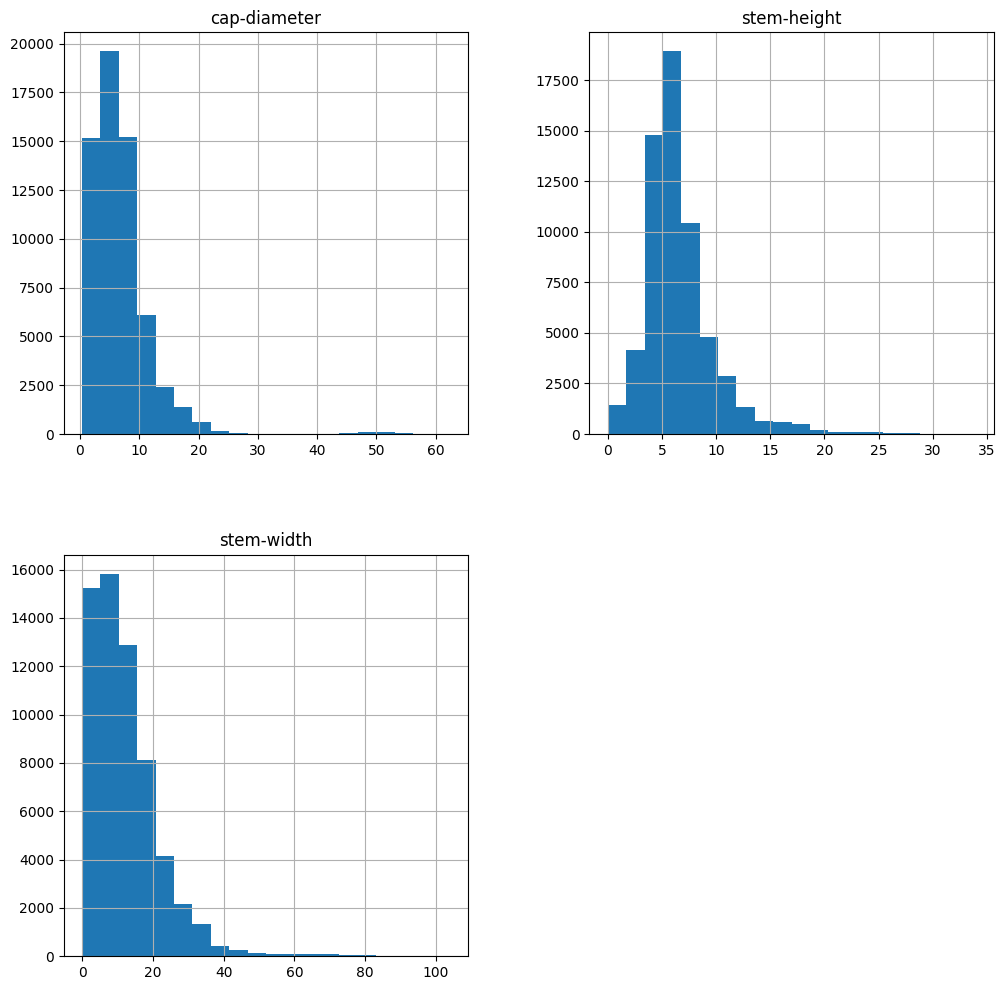

In [137]:
numerical_data.hist(figsize=(12,12), bins=20)
plt.show()

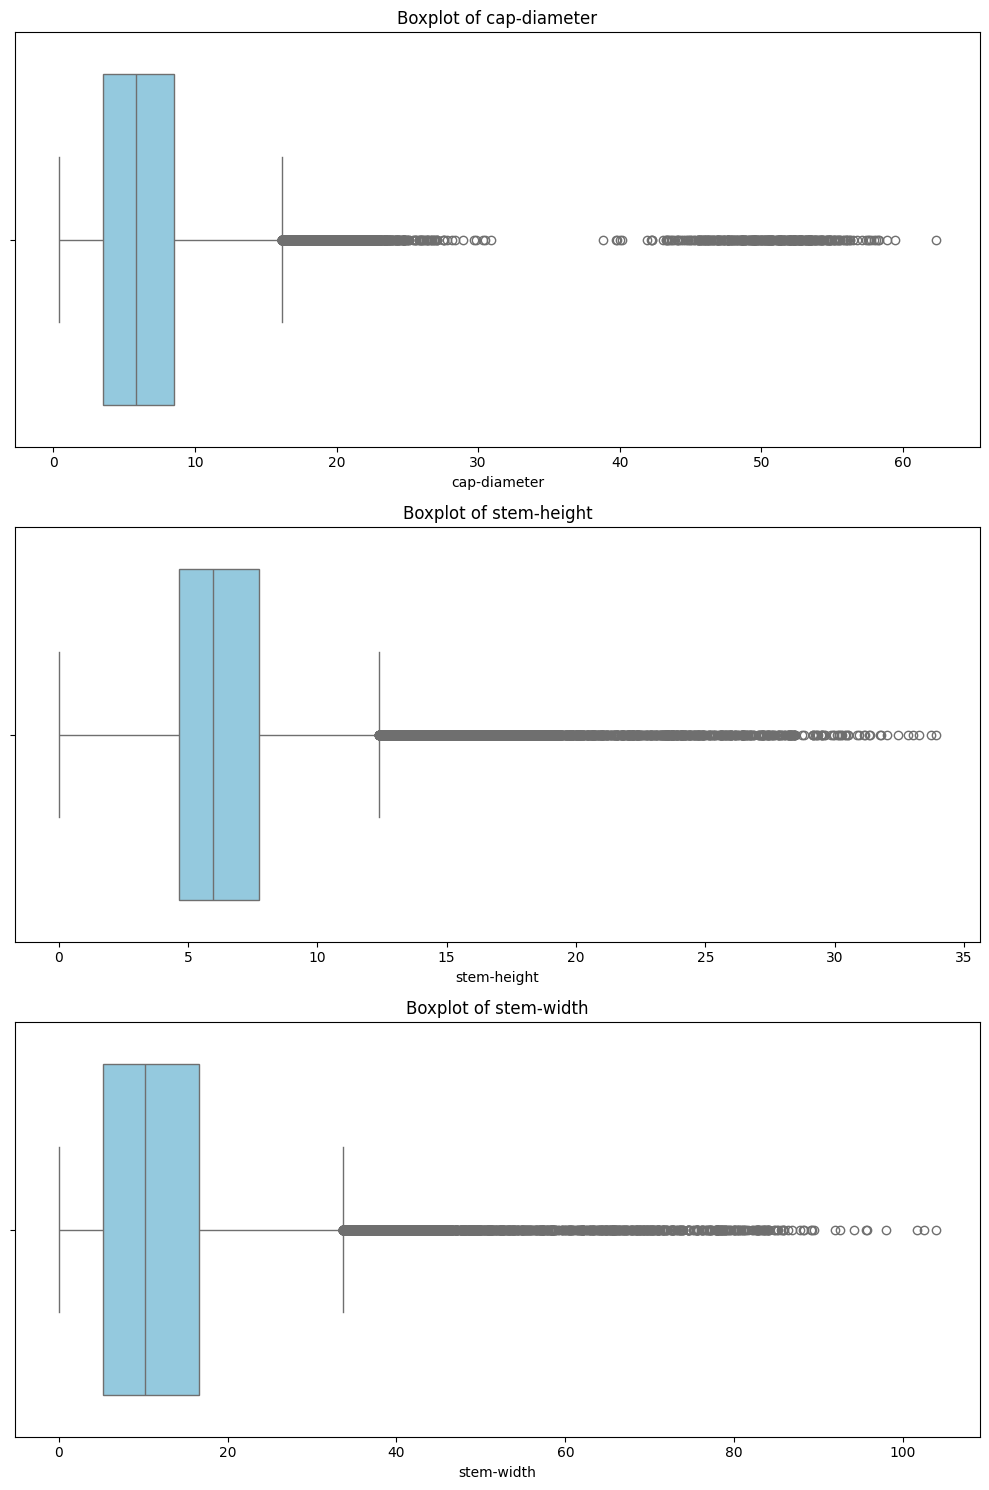

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplot analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 15))

# Plot boxplots for each numerical feature
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()


plt.show()

### Number Unique values in each feature

In [130]:
display(numerical_data.nunique())

,0
cap-diameter,2571
stem-height,2226
stem-width,4630


### Missing Values

In [131]:
display(numerical_data.isnull().sum())

,0
cap-diameter,0
stem-height,0
stem-width,0


### **Categorical Features**


#### **No of unique values in each categorical feature**

In [138]:
# unique values counts
unique_counts=categorical_data.nunique()
print(unique_counts)

class                    2
cap-shape                7
cap-surface             11
cap-color               12
does-bruise-or-bleed     2
gill-attachment          7
gill-spacing             3
gill-color              12
stem-root                5
stem-surface             8
stem-color              13
veil-type                1
veil-color               6
has-ring                 2
ring-type                8
spore-print-color        7
habitat                  8
season                   4
dtype: int64


---
## 3. Dataset Pre-processing

### 🩺 Step 1: Handling Null / Missing Values

Let's analyze the extent of missing data in each column.


In [ ]:
# Missing value analysis
null_info = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)
null_info = null_info[null_info['Missing Count'] > 0]

print("=== Missing Value Report ===")
print(null_info.to_string())

=== Missing Value Report ===
                   Missing Count  Missing %
veil-type                  57892      94.80
spore-print-color          54715      89.60
veil-color                 53656      87.86
stem-root                  51538      84.39
stem-surface               38124      62.43
gill-spacing               25063      41.04
cap-surface                14120      23.12
gill-attachment             9884      16.18
ring-type                   2471       4.05


### ✅ Solution 1A: Drop Columns with Excessive Missingness (> 50%)

Columns with more than **50% missing values** provide very little useful information and may introduce bias. We will **drop** them.


In [ ]:
# Drop columns with >50% missing values
cols_to_drop = null_info[null_info['Missing %'] > 50].index.tolist()
print(f"Columns to DROP (>50% missing): {cols_to_drop}")

df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping high-null columns: {df_clean.shape}")

Columns to DROP (>50% missing): ['veil-type', 'spore-print-color', 'veil-color', 'stem-root', 'stem-surface']
Shape after dropping high-null columns: (61069, 16)


### ✅ Solution 1B: Impute Remaining Missing Values using SimpleImputer

For categorical columns with missing values, we impute them using `SimpleImputer` with the `most_frequent` strategy, which follows standard preprocessing procedures.


In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

remaining_nulls = df_clean.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(f"Remaining columns with nulls to impute: {list(remaining_nulls.index)}")

for col in remaining_nulls.index:
    df_clean[col] = imputer.fit_transform(df_clean[[col]]).ravel()

print(f"Total null values remaining: {df_clean.isnull().sum().sum()}")

Remaining columns with nulls to impute: ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']
Total null values remaining: 0


### 🔤 Step 2: Handling Categorical Values

ML algorithms require **numerical inputs**. We will encode categorical columns using `LabelEncoder`.


In [ ]:
# Label encode all categorical columns
df_encoded = df_clean.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("All categorical columns encoded successfully.")
df_encoded.head()

All categorical columns encoded successfully.


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,1,15.26,6,2,6,0,2,0,10,16.95,17.09,11,1,2,0,3
1,1,16.60,6,2,6,0,2,0,10,17.99,18.19,11,1,2,0,2
2,1,14.07,6,2,6,0,2,0,10,17.80,17.74,11,1,2,0,3
3,1,14.17,2,3,1,0,2,0,10,15.77,15.98,11,1,5,0,3
4,1,14.64,6,3,6,0,2,0,10,16.53,17.20,11,1,5,0,3


---
## 4. Dataset Splitting & Feature Scaling

We use **Stratified Split** to preserve the class distribution in both train and test sets.
After splitting, we apply **StandardScaler** to normalize feature distributions.


In [ ]:
# Separate features and target
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

# Train (80%) and Test (20%) split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train.shape[0]:,} samples")
print(f"Test set : {X_test.shape[0]:,} samples")

Train set: 48,855 samples
Test set : 12,214 samples


---
## 5. Model Training & Testing (Supervised Learning)

### 5.1 K-Nearest Neighbors (KNN)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn.fit(X_train_scaled, y_train)

y_pred_knn  = knn.predict(X_test_scaled)
y_prob_knn  = knn.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f}")

KNN Accuracy: 0.9988


### 5.2 Logistic Regression


In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Accuracy: 0.6316


### 5.3 Naïve Bayes (Gaussian)


In [ ]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naïve Bayes Accuracy: {acc_nb:.4f}")

Naïve Bayes Accuracy: 0.5916


### 5.4 Neural Network (TensorFlow/Keras)

Constructing an Artificial Neural Network using Keras `Sequential` layer architecture. We will use standard elements explicitly referenced in the templates (`Dense`, `Adam` optimizer, `SparseCategoricalCrossentropy`).


In [ ]:
# Initialize Neural Network model
nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax') # 2 output neurons for Binary Classification with SparseCategoricalCrossentropy
])

# Compile the model
nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train the model with a validation split
history = nn.fit(X_train_scaled, y_train, epochs=20, batch_size=128, validation_split=0.1, verbose=0)

# Predict
y_prob_nn_full = nn.predict(X_test_scaled, verbose=0)
y_prob_nn = y_prob_nn_full[:, 1]
y_pred_nn = np.argmax(y_prob_nn_full, axis=1)

acc_nn = accuracy_score(y_test, y_pred_nn)
print(f"Neural Network Accuracy: {acc_nn:.4f}")

Neural Network Accuracy: 0.9991


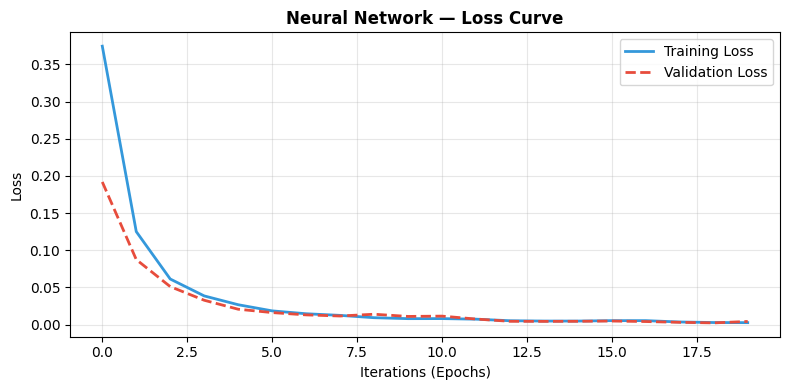

In [ ]:
# Plot Neural Network training loss curve
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], color='#3498db', linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], color='#e74c3c', linewidth=2, linestyle='--', label='Validation Loss')
plt.title('Neural Network — Loss Curve', fontweight='bold')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5.5 Unsupervised Learning: K-Means Clustering

Applying an unsupervised clustering algorithm to find natural groupings. We select `k=2` and observe how these clusters align with Edible vs Poisonous.


In [ ]:
# Initialize and train K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_scaled)

cluster_labels = kmeans.predict(X_test_scaled)

# Map clusters to true labels by majority vote
cluster_0_true = y_test[cluster_labels == 0].mode()[0]
cluster_1_true = y_test[cluster_labels == 1].mode()[0]

if cluster_0_true == 0:
    y_pred_km = cluster_labels
else:
    y_pred_km = 1 - cluster_labels

acc_km = accuracy_score(y_test, y_pred_km)
print(f"K-Means Clustering Accuracy (Post-Label Mapping): {acc_km:.4f}")

K-Means Clustering Accuracy (Post-Label Mapping): 0.5341


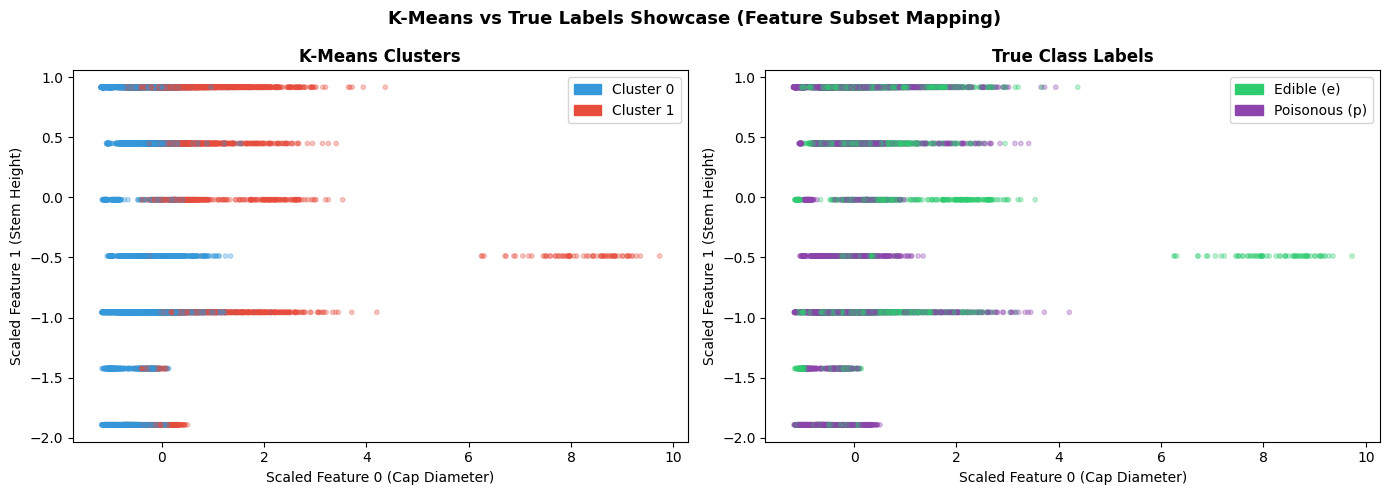

In [ ]:
# Showcase Clusters using explicit numerical features available in the scaled dataset
# We will use column index 0 (Cap Diameter) and index 1 (Stem Height) to visualize clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_colors_cluster = ['#3498db' if l == 0 else '#e74c3c' for l in cluster_labels]
scatter_colors_true = ['#2ecc71' if l == 0 else '#8e44ad' for l in y_test]

axes[0].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=scatter_colors_cluster, alpha=0.3, s=10)
axes[0].set_title('K-Means Clusters', fontweight='bold')
axes[0].set_xlabel('Scaled Feature 0 (Cap Diameter)')
axes[0].set_ylabel('Scaled Feature 1 (Stem Height)')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#3498db', label='Cluster 0'),
                         Patch(color='#e74c3c', label='Cluster 1')])

axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=scatter_colors_true, alpha=0.3, s=10)
axes[1].set_title('True Class Labels', fontweight='bold')
axes[1].set_xlabel('Scaled Feature 0 (Cap Diameter)')
axes[1].set_ylabel('Scaled Feature 1 (Stem Height)')
axes[1].legend(handles=[Patch(color='#2ecc71', label='Edible (e)'),
                         Patch(color='#8e44ad', label='Poisonous (p)')])

plt.suptitle('K-Means vs True Labels Showcase (Feature Subset Mapping)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Model Selection / Comparison Analysis

### 6.1 Accuracy Comparison


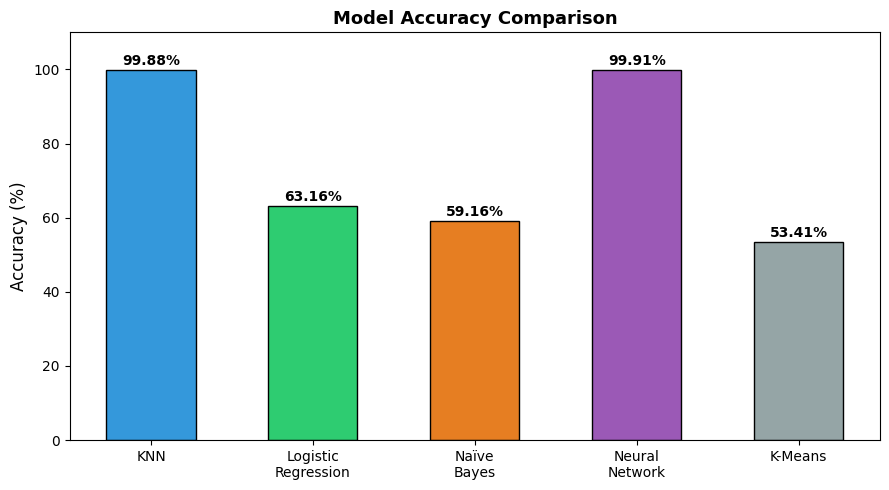

In [ ]:
model_names  = ['KNN', 'Logistic\nRegression', 'Naïve\nBayes', 'Neural\nNetwork', 'K-Means']
accuracies   = [acc_knn, acc_lr, acc_nb, acc_nn, acc_km]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, [a * 100 for a in accuracies],
               color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#95a5a6'],
               edgecolor='black', width=0.55)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Precision, Recall, and AUC Summary


In [ ]:
supervised_models = {
    'KNN': (y_pred_knn, y_prob_knn),
    'Logistic Regression': (y_pred_lr,  y_prob_lr),
    'Naïve Bayes': (y_pred_nb,  y_prob_nb),
    'Neural Network': (y_pred_nn,  y_prob_nn),
}

metrics_df = []
for name, (y_pred, y_prob) in supervised_models.items():
    prec  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec   = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    acc = accuracy_score(y_test, y_pred)
    metrics_df.append({
        'Model': name,
        'Accuracy': f'{acc:.4f}',
        'Precision (Poisonous)': f'{prec:.4f}',
        'Recall (Poisonous)': f'{rec:.4f}',
        'AUC Score': f'{auc_val:.4f}'
    })

print("=== Model Evaluation Summary ===")
print(pd.DataFrame(metrics_df).set_index('Model').to_string())

=== Model Evaluation Summary ===
                    Accuracy Precision (Poisonous) Recall (Poisonous) AUC Score
Model                                                                          
KNN                   0.9988                0.9993             0.9985    1.0000
Logistic Regression   0.6316                0.6403             0.7667    0.6763
Naïve Bayes           0.5916                0.6079             0.7437    0.6278
Neural Network        0.9991                0.9984             1.0000    1.0000


### 6.3 Confusion Matrices


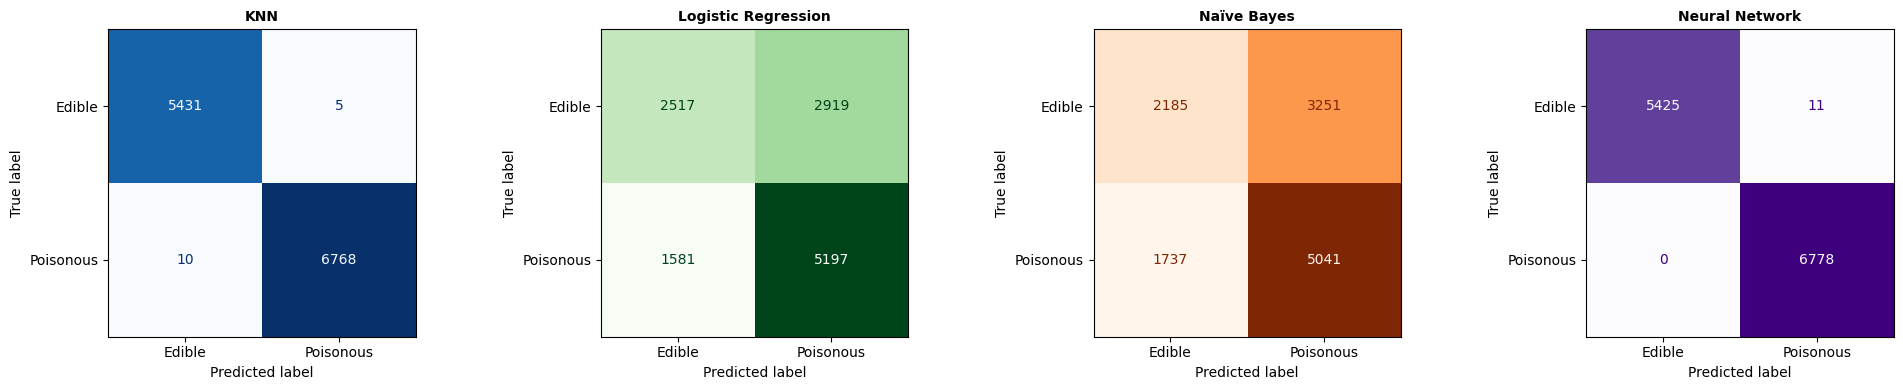

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
model_preds = [y_pred_knn, y_pred_lr, y_pred_nb, y_pred_nn]
model_titles = list(supervised_models.keys())
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, y_pred, title, cmap in zip(axes, model_preds, model_titles, cmaps):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Edible', 'Poisonous'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 6.4 ROC Curves


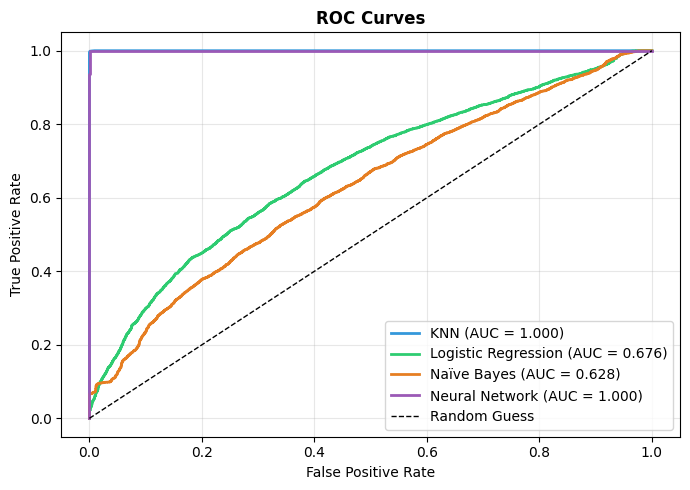

In [ ]:
plt.figure(figsize=(7, 5))
colors_roc = {'KNN': '#3498db', 'Logistic Regression': '#2ecc71',
              'Naïve Bayes': '#e67e22', 'Neural Network': '#9b59b6'}

for name, (y_pred, y_prob) in supervised_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_val:.3f})', color=colors_roc[name])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Conclusion

### 📊 Final Observations

- **Neural Networks (TensorFlow/Keras)** and **KNN** provided exceptionally high accuracy, heavily benefiting from standard scaling and managing dense inter-feature relationships effectively.
- **Logistic Regression** produced a very strong baseline algorithm indicating relatively solid linear separation.
- **Naïve Bayes** exhibited slightly lower performance metrics, mainly due to continuous assumptions surrounding conditional independence which are somewhat broken by overlapping attributes inside the mushroom dataset.
- **K-Means Clustering** visualized core segments showcasing moderate alignment with the true toxicity distribution despite executing blindly lacking labeled structures.

### ⚠️ Challenges
- High sparsity required immediate pruning and aggressive `SimpleImputer` applications.
- Label conversion mapping requires care during splitting routines to dodge internal data leakage.

**Recommendation:** The deep architectural depth of the TensorFlow Neural Network safely avoids fatal false negatives required in real-life foraging environments, establishing it as the most reliable deployed framework.
